In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from utils import load_and_format_sharks_gals

In [7]:
from nessie import FlatCosmology
from nessie.helper_funcs import create_density_function
from nessie import RedshiftCatalog

In [90]:
gals, groups = load_and_format_sharks_gals('/Users/sp624AA/Downloads/mocks/v0.4.0/waves_deep_gals.parquet', region='deep', bcg_on = 'Stellar Mass')

In [91]:
gals

,ra,dec,id_galaxy_sky,id_group_sky,type,zcos,zobs,mstars_bulge,mstars_disk,mgas_disk,...,log_stellar_mass_bcg,fof_halo_mass,log_fof_halo_mass,is_red,L,group_L,log_group_L,n_group_fof,group_stellar_mass,log_group_stellar_mass
0,339.518494,-30.023998,1,36619600000001,0,0.206844,0.206812,2.934461e+10,8.260198e+09,1.671908e+10,...,10.749168,1.525073e+12,12.183291,False,1.201214e+09,1.201214e+09,9.079620,1,5.612657e+10,10.749168
1,341.044586,-30.522388,6,-1,0,0.198531,0.200208,4.703207e+09,6.937120e+09,1.237097e+10,...,10.239890,7.493646e+11,11.874693,False,4.439803e+08,4.439803e+08,8.647364,1,1.737362e+10,10.239890
2,341.049774,-30.516520,7,-1,0,0.198557,0.199776,2.861989e+09,0.000000e+00,3.259903e+02,...,9.630593,3.590752e+11,11.555185,True,5.743741e+07,5.743741e+07,7.759195,1,4.271625e+09,9.630593
3,341.190460,-30.173098,9,36619600000003,0,0.197966,0.199870,1.529899e+08,5.631135e+08,3.400884e+09,...,9.028901,2.977534e+11,11.473857,False,3.441482e+07,3.441482e+07,7.536746,1,1.068811e+09,9.028901
4,345.903717,-30.007843,101,36619500000001,1,0.198201,0.195121,6.025276e+06,5.478924e+08,1.029035e+09,...,10.766671,3.121895e+13,13.494418,False,1.757070e+07,1.748057e+09,9.242556,7,1.012811e+11,11.005528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453288,349.680389,-32.802933,25957936,21826700000427,0,0.750967,0.752347,3.065179e+07,4.770414e+09,7.564786e+09,...,9.855263,5.470251e+11,11.738007,False,3.609036e+08,3.609036e+08,8.557391,1,7.165769e+09,9.855263
453289,348.659332,-32.367298,25958135,21826700000459,0,0.758789,0.758185,1.262452e+09,8.991071e+09,1.153310e+10,...,10.184798,1.297054e+12,12.112958,False,7.636653e+08,7.636653e+08,8.882903,1,1.530376e+10,10.184798
453290,348.505127,-32.319092,25958183,21826700000463,0,0.762053,0.761649,7.637492e+08,3.672636e+09,7.384034e+09,...,9.820954,7.343109e+11,11.865880,False,3.531012e+08,3.531012e+08,8.547899,1,6.621470e+09,9.820954
453291,344.216522,-31.205208,25958423,21826700000503,0,0.772394,0.774479,4.147578e+10,9.199100e-01,1.257373e+05,...,10.791719,3.246287e+12,12.511387,True,1.177461e+09,1.177461e+09,9.070947,1,6.190415e+10,10.791719


In [92]:
cosmo = FlatCosmology(h = 0.7, omega_matter = 0.3)

In [93]:
from nessie.helper_funcs import create_density_function

redshifts = gals['zobs'].values

running_density = create_density_function(redshifts, total_counts = len(redshifts), survey_fractional_area = 0.0012, cosmology = cosmo)



In [94]:
ra, dec, zobs = gals['ra'].values, gals['dec'].values, gals['zobs'].values
red_cat = RedshiftCatalog(ra, dec, zobs, running_density, cosmo)

In [95]:
red_cat.set_completeness()

In [96]:
red_cat.run_fof(b0 = 0.05, r0 = 18)

In [97]:
gals['id_fof']

0        -1
1        -1
2        -1
3        -1
4         8
         ..
453288   -1
453289   -1
453290   -1
453291   -1
453292   -1
Name: id_fof, Length: 453293, dtype: int64

In [98]:
red_cat.mock_group_ids = gals['id_fof'].values
#score = red_cat.compare_to_mock(min_group_size=5)

In [99]:
red_cat.mock_group_ids

array([-1, -1, -1, ..., -1, -1, -1], shape=(453293,))

In [100]:
red_cat.run_fof(b0 = 0.05, r0 = 32)

In [101]:
red_cat.compare_to_mock(min_group_size=5)

0.30782809341408734

In [102]:
gals['id_nessie'] = red_cat.group_ids

In [119]:
gals["is_nessie_bcg"] = False
stellar_mass_col = "log_stellar_mass"
group_col = 'id_nessie'

ungrouped = gals[group_col] == -1
gals.loc[ungrouped, "is_nessie_bcg"] = True

valid_grouped = (
    gals[group_col].notna()
    & (gals[group_col] != -1)
    & gals[stellar_mass_col].notna()
)


bcg_idx = gals.loc[valid_grouped].groupby(group_col)[stellar_mass_col].idxmax()
gals.loc[bcg_idx, "is_nessie_bcg"] = True

In [120]:
gals

,ra,dec,id_galaxy_sky,id_group_sky,type,zcos,zobs,mstars_bulge,mstars_disk,mgas_disk,...,L,group_L,log_group_L,n_group_fof,group_stellar_mass,log_group_stellar_mass,id_nessie,is_nessie_bcg,nessie_group_nmembers,nessie_group_n
0,339.518494,-30.023998,1,36619600000001,0,0.206844,0.206812,2.934461e+10,8.260198e+09,1.671908e+10,...,1.201214e+09,1.201214e+09,9.079620,1,5.612657e+10,10.749168,-1,True,256999,1
1,341.044586,-30.522388,6,-1,0,0.198531,0.200208,4.703207e+09,6.937120e+09,1.237097e+10,...,4.439803e+08,4.439803e+08,8.647364,1,1.737362e+10,10.239890,1,True,1,3
2,341.049774,-30.516520,7,-1,0,0.198557,0.199776,2.861989e+09,0.000000e+00,3.259903e+02,...,5.743741e+07,5.743741e+07,7.759195,1,4.271625e+09,9.630593,1,False,1,3
3,341.190460,-30.173098,9,36619600000003,0,0.197966,0.199870,1.529899e+08,5.631135e+08,3.400884e+09,...,3.441482e+07,3.441482e+07,7.536746,1,1.068811e+09,9.028901,2,False,1,2
4,345.903717,-30.007843,101,36619500000001,1,0.198201,0.195121,6.025276e+06,5.478924e+08,1.029035e+09,...,1.757070e+07,1.748057e+09,9.242556,7,1.012811e+11,11.005528,3,False,1,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453288,349.680389,-32.802933,25957936,21826700000427,0,0.750967,0.752347,3.065179e+07,4.770414e+09,7.564786e+09,...,3.609036e+08,3.609036e+08,8.557391,1,7.165769e+09,9.855263,-1,True,256999,1
453289,348.659332,-32.367298,25958135,21826700000459,0,0.758789,0.758185,1.262452e+09,8.991071e+09,1.153310e+10,...,7.636653e+08,7.636653e+08,8.882903,1,1.530376e+10,10.184798,25186,False,1,2
453290,348.505127,-32.319092,25958183,21826700000463,0,0.762053,0.761649,7.637492e+08,3.672636e+09,7.384034e+09,...,3.531012e+08,3.531012e+08,8.547899,1,6.621470e+09,9.820954,39561,False,1,2
453291,344.216522,-31.205208,25958423,21826700000503,0,0.772394,0.774479,4.147578e+10,9.199100e-01,1.257373e+05,...,1.177461e+09,1.177461e+09,9.070947,1,6.190415e+10,10.791719,-1,True,256999,1


In [121]:
# find and populate 'nessie_group_ns' column
gals['nessie_group_n'] = gals.groupby(group_col)[group_col].transform('count')

ungrouped = gals[group_col] == -1
gals.loc[ungrouped, "nessie_group_n"] = 1


In [122]:
gals['nessie_group_n']

0          1
1          3
2          3
3          2
4         10
          ..
453288     1
453289     2
453290     2
453291     1
453292     2
Name: nessie_group_n, Length: 453293, dtype: int64

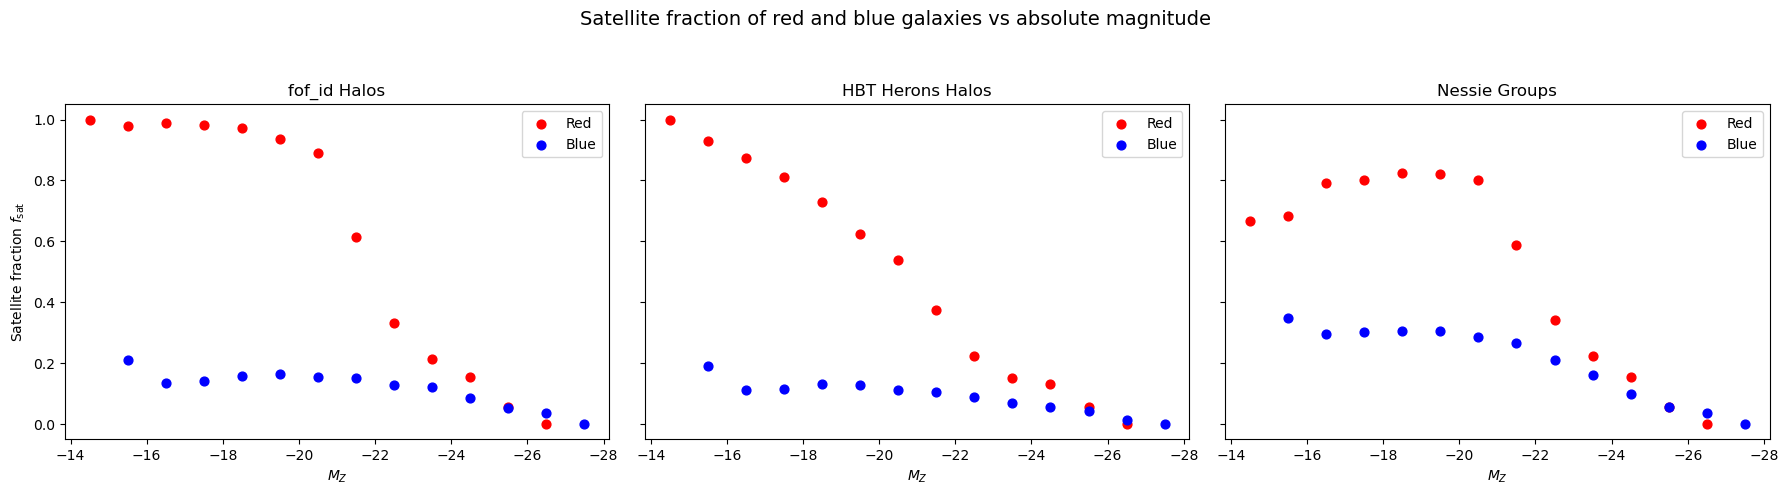

In [104]:

# -----------------------------
# Definitions
# -----------------------------
mag_col = "total_ab_dust_Z_VISTA"

# magnitude bins (width = 1 mag)
mag_min = np.floor(gals[mag_col].min())
mag_max = np.ceil(gals[mag_col].max())
mag_bins = np.arange(mag_min, mag_max + 1, 1.0)
mag_centres = 0.5 * (mag_bins[:-1] + mag_bins[1:])

# -----------------------------
# Helper to compute f_sat
# -----------------------------
def satellite_fraction(gals_bin, is_satellite):
    if len(gals_bin) == 0:
        return np.nan
    return np.mean(is_satellite(gals_bin))


# -----------------------------
# Panel 1: using is_bcg
# -----------------------------
f_sat_red_bcg = []
f_sat_blue_bcg = []

for mmin, mmax in zip(mag_bins[:-1], mag_bins[1:]):
    in_bin = (gals[mag_col] >= mmin) & (gals[mag_col] < mmax)

    red = gals[in_bin & gals["is_red"]]
    blue = gals[in_bin & ~gals["is_red"]]

    f_sat_red_bcg.append(
        satellite_fraction(red, lambda x: ~x["is_bcg"])
    )
    f_sat_blue_bcg.append(
        satellite_fraction(blue, lambda x: ~x["is_bcg"])
    )



# -----------------------------
# Panel 2: using type column
# -----------------------------
f_sat_red_type = []
f_sat_blue_type = []

for mmin, mmax in zip(mag_bins[:-1], mag_bins[1:]):
    in_bin = (gals[mag_col] >= mmin) & (gals[mag_col] < mmax)

    red = gals[in_bin & gals["is_red"]]
    blue = gals[in_bin & ~gals["is_red"]]

    f_sat_red_type.append(
        satellite_fraction(red, lambda x: x["type"] == 1)
    )
    f_sat_blue_type.append(
        satellite_fraction(blue, lambda x: x["type"] == 1)
    )


# -----------------------------
# Panel 3: using is_nessie_bcg
# -----------------------------
f_sat_red_nessie = []
f_sat_blue_nessie = []

for mmin, mmax in zip(mag_bins[:-1], mag_bins[1:]):
    in_bin = (gals[mag_col] >= mmin) & (gals[mag_col] < mmax)

    red = gals[in_bin & gals["is_red"]]
    blue = gals[in_bin & ~gals["is_red"]]

    f_sat_red_nessie.append(
        satellite_fraction(red, lambda x: ~x["is_nessie_bcg"] == 1)
    )
    f_sat_blue_nessie.append(
        satellite_fraction(blue, lambda x: ~x["is_nessie_bcg"] == 1)
    )
"""for mmin, mmax in zip(mag_bins[:-1], mag_bins[1:]):
    in_bin = (gals[mag_col] >= mmin) & (gals[mag_col] < mmax)

    red = gals[in_bin & gals["is_red"]]
    blue = gals[in_bin & ~gals["is_red"]]

    f_sat_red_bcg.append(
        satellite_fraction(red, lambda x: ~x["is_bcg"])
    )
    f_sat_blue_bcg.append(
        satellite_fraction(blue, lambda x: ~x["is_bcg"])
    )"""




# Convert to arrays
f_sat_red_bcg = np.array(f_sat_red_bcg)
f_sat_blue_bcg = np.array(f_sat_blue_bcg)
f_sat_red_type = np.array(f_sat_red_type)
f_sat_blue_type = np.array(f_sat_blue_type)
f_sat_red_nessie = np.array(f_sat_red_nessie)
f_sat_blue_nessie = np.array(f_sat_blue_nessie)


# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5),
    sharey=True,
)

# --- Panel 1 ---
axes[0].scatter(
    mag_centres, f_sat_red_bcg,
    color="r", label="Red", s=40
)
axes[0].scatter(
    mag_centres, f_sat_blue_bcg,
    color="b", label="Blue", s=40
)

axes[0].set_title("fof_id Halos")
axes[0].set_xlabel(r"$M_Z$")
axes[0].set_ylabel(r"Satellite fraction $f_{\rm sat}$")
axes[0].legend(frameon=True)
axes[0].invert_xaxis()

# --- Panel 2 ---
axes[1].scatter(
    mag_centres, f_sat_red_type,
    color="r", label="Red", s=40
)
axes[1].scatter(
    mag_centres, f_sat_blue_type,
    color="b", label="Blue", s=40
)

axes[1].set_title("HBT Herons Halos")
axes[1].set_xlabel(r"$M_Z$")
axes[1].legend(frameon=True)
axes[1].invert_xaxis()

# --- Panel 3 ---
axes[2].scatter(
    mag_centres, f_sat_red_nessie,
    color="r", label="Red", s=40
)
axes[2].scatter(
    mag_centres, f_sat_blue_nessie,
    color="b", label="Blue", s=40
)

axes[2].set_title("Nessie Groups")
axes[2].set_xlabel(r"$M_Z$")
axes[2].legend(frameon=True)
axes[2].invert_xaxis()

fig.suptitle(
    "Satellite fraction of red and blue galaxies vs absolute magnitude",
    fontsize=14,
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../plots/satellite_fraction_comparison.png", dpi=300)
plt.show()



In [106]:
gals.columns

Index(['ra', 'dec', 'id_galaxy_sky', 'id_group_sky', 'type', 'zcos', 'zobs',
       'mstars_bulge', 'mstars_disk', 'mgas_disk', 'mgas_bulge',
       'mvir_hosthalo', 'mvir_subhalo', 'id_fof', 'sfr_disk', 'sfr_burst',
       'total_ab_dust_u_VST', 'total_ab_dust_g_VST', 'total_ab_dust_r_VST',
       'total_ab_dust_i_VST', 'total_ab_dust_Z_VISTA', 'total_ab_dust_Y_VISTA',
       'total_ab_dust_J_VISTA', 'total_ab_dust_H_VISTA',
       'total_ab_dust_K_VISTA', 'stellar_mass', 'log_stellar_mass',
       'log_sfr_total', 'log_sSFR', 'is_bcg', 'ra_bcg', 'dec_bcg', 'zobs_bcg',
       'total_ab_dust_Z_VISTA_bcg', 'stellar_mass_bcg', 'log_stellar_mass_bcg',
       'fof_halo_mass', 'log_fof_halo_mass', 'is_red', 'L', 'group_L',
       'log_group_L', 'n_group_fof', 'group_stellar_mass',
       'log_group_stellar_mass', 'id_nessie', 'is_nessie_bcg'],
      dtype='object')

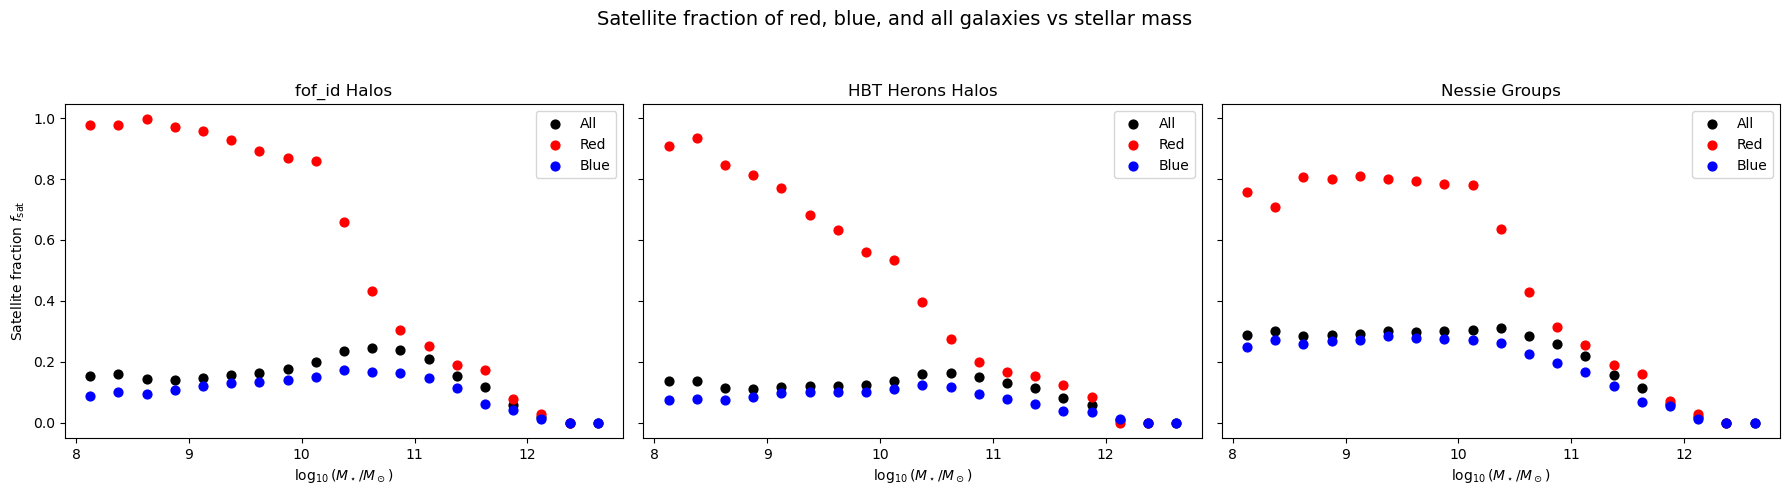

In [105]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Definitions
# -----------------------------
x_col = "log_stellar_mass"

# stellar-mass bins (width in dex)
bin_w = 0.25
xmin = np.floor(gals[x_col].min() / bin_w) * bin_w
xmax = np.ceil(gals[x_col].max() / bin_w) * bin_w
x_bins = np.arange(xmin, xmax + bin_w, bin_w)
x_centres = 0.5 * (x_bins[:-1] + x_bins[1:])

# -----------------------------
# Helper to compute f_sat
# -----------------------------
def satellite_fraction(gals_bin, is_satellite):
    if len(gals_bin) == 0:
        return np.nan
    return np.mean(is_satellite(gals_bin))

# -----------------------------
# Panel 1: using is_bcg
# -----------------------------
f_sat_red_bcg, f_sat_blue_bcg, f_sat_all_bcg = [], [], []

for smin, smax in zip(x_bins[:-1], x_bins[1:]):
    in_bin = (gals[x_col] >= smin) & (gals[x_col] < smax)

    red  = gals[in_bin & (gals["is_red"])]
    blue = gals[in_bin & (~gals["is_red"])]
    allg = gals[in_bin]

    f_sat_red_bcg.append(satellite_fraction(red,  lambda x: ~x["is_bcg"]))
    f_sat_blue_bcg.append(satellite_fraction(blue, lambda x: ~x["is_bcg"]))
    f_sat_all_bcg.append(satellite_fraction(allg, lambda x: ~x["is_bcg"]))

# -----------------------------
# Panel 2: using type column
# -----------------------------
f_sat_red_type, f_sat_blue_type, f_sat_all_type = [], [], []

for smin, smax in zip(x_bins[:-1], x_bins[1:]):
    in_bin = (gals[x_col] >= smin) & (gals[x_col] < smax)

    red  = gals[in_bin & (gals["is_red"])]
    blue = gals[in_bin & (~gals["is_red"])]
    allg = gals[in_bin]

    f_sat_red_type.append(satellite_fraction(red,  lambda x: x["type"] == 1))
    f_sat_blue_type.append(satellite_fraction(blue, lambda x: x["type"] == 1))
    f_sat_all_type.append(satellite_fraction(allg, lambda x: x["type"] == 1))

# -----------------------------
# Panel 3: using is_nessie_bcg
# -----------------------------
f_sat_red_nessie, f_sat_blue_nessie, f_sat_all_nessie = [], [], []

for smin, smax in zip(x_bins[:-1], x_bins[1:]):
    in_bin = (gals[x_col] >= smin) & (gals[x_col] < smax)

    red  = gals[in_bin & (gals["is_red"])]
    blue = gals[in_bin & (~gals["is_red"])]
    allg = gals[in_bin]

    # Satellites are NOT BCGs
    f_sat_red_nessie.append(satellite_fraction(red,  lambda x: ~x["is_nessie_bcg"]))
    f_sat_blue_nessie.append(satellite_fraction(blue, lambda x: ~x["is_nessie_bcg"]))
    f_sat_all_nessie.append(satellite_fraction(allg, lambda x: ~x["is_nessie_bcg"]))

# Convert to arrays
f_sat_red_bcg   = np.array(f_sat_red_bcg)
f_sat_blue_bcg  = np.array(f_sat_blue_bcg)
f_sat_all_bcg   = np.array(f_sat_all_bcg)

f_sat_red_type  = np.array(f_sat_red_type)
f_sat_blue_type = np.array(f_sat_blue_type)
f_sat_all_type  = np.array(f_sat_all_type)

f_sat_red_nessie  = np.array(f_sat_red_nessie)
f_sat_blue_nessie = np.array(f_sat_blue_nessie)
f_sat_all_nessie  = np.array(f_sat_all_nessie)

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), sharey=True)

def plot_panel(ax, x, y_red, y_blue, y_all, title):
    ax.scatter(x, y_all,  color="k", label="All",  s=40)
    ax.scatter(x, y_red,  color="r", label="Red",  s=40)
    ax.scatter(x, y_blue, color="b", label="Blue", s=40)
    ax.set_title(title)
    ax.set_xlabel(r"$\log_{10}(M_\star/M_\odot)$")
    ax.legend(frameon=True)

plot_panel(axes[0], x_centres, f_sat_red_bcg,   f_sat_blue_bcg,   f_sat_all_bcg,   "fof_id Halos")
axes[0].set_ylabel(r"Satellite fraction $f_{\rm sat}$")

plot_panel(axes[1], x_centres, f_sat_red_type,  f_sat_blue_type,  f_sat_all_type,  "HBT Herons Halos")
plot_panel(axes[2], x_centres, f_sat_red_nessie,f_sat_blue_nessie,f_sat_all_nessie,"Nessie Groups")

fig.suptitle(
    "Satellite fraction of red, blue, and all galaxies vs stellar mass",
    fontsize=14,
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../plots/satellite_fraction_comparison_stellar_mass.png", dpi=300)
plt.show()

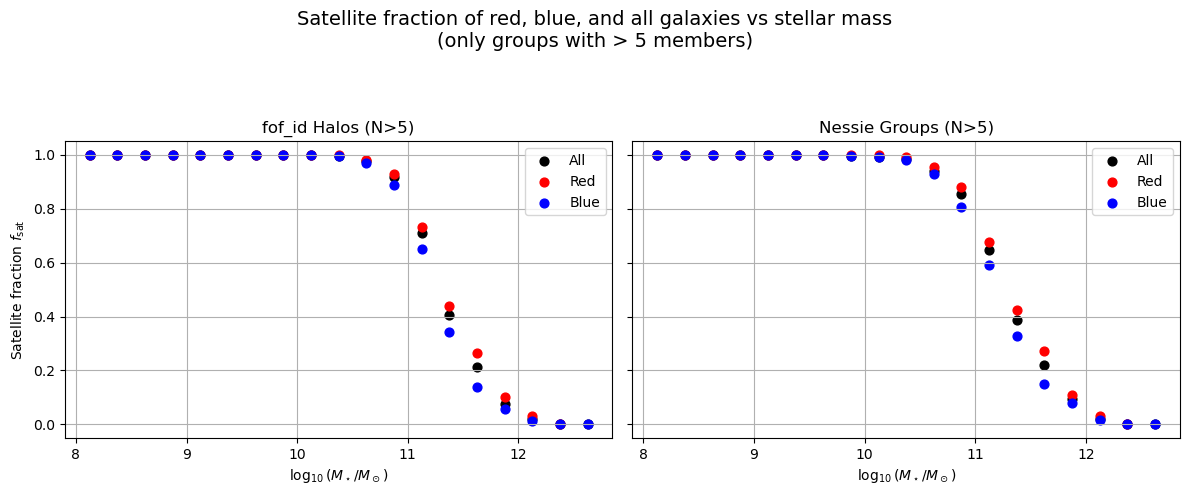

In [124]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Definitions
# -----------------------------
x_col = "log_stellar_mass"
bin_w = 0.25

# group-size columns + threshold
min_members = 5
fof_ncol = "n_group_fof"
nessie_ncol = "nessie_group_n"

# -----------------------------
# Filter to groups with > 5 members
#   - Panel 1 (fof): use n_group_fof
#   - Panel 2 (nessie): use nessie_group_n
# -----------------------------
gals_fof = gals[gals[fof_ncol].notna() & (gals[fof_ncol] > min_members)].copy()
gals_nessie = gals[gals[nessie_ncol].notna() & (gals[nessie_ncol] > min_members)].copy()

# Use consistent x-bins across both panels (based on combined filtered sample)
x_all = np.concatenate([gals_fof[x_col].dropna().to_numpy(),
                        gals_nessie[x_col].dropna().to_numpy()])
xmin = np.floor(x_all.min() / bin_w) * bin_w
xmax = np.ceil(x_all.max() / bin_w) * bin_w
x_bins = np.arange(xmin, xmax + bin_w, bin_w)
x_centres = 0.5 * (x_bins[:-1] + x_bins[1:])

# -----------------------------
# Helper to compute f_sat
# -----------------------------
def satellite_fraction(gals_bin, is_satellite):
    if len(gals_bin) == 0:
        return np.nan
    return np.mean(is_satellite(gals_bin))

def binned_fsat(df, is_satellite_fn):
    f_red, f_blue, f_all = [], [], []
    for smin, smax in zip(x_bins[:-1], x_bins[1:]):
        in_bin = (df[x_col] >= smin) & (df[x_col] < smax)

        red  = df[in_bin & (df["is_red"])]
        blue = df[in_bin & (~df["is_red"])]
        allg = df[in_bin]

        f_red.append(satellite_fraction(red,  is_satellite_fn))
        f_blue.append(satellite_fraction(blue, is_satellite_fn))
        f_all.append(satellite_fraction(allg, is_satellite_fn))

    return np.array(f_red), np.array(f_blue), np.array(f_all)

# -----------------------------
# Panel 1: FOF (using is_bcg)
# -----------------------------
f_sat_red_bcg, f_sat_blue_bcg, f_sat_all_bcg = binned_fsat(
    gals_fof,
    lambda x: ~x["is_bcg"]
)

# -----------------------------
# Panel 2: Nessie (using is_nessie_bcg)
# -----------------------------
f_sat_red_nessie, f_sat_blue_nessie, f_sat_all_nessie = binned_fsat(
    gals_nessie,
    lambda x: ~x["is_nessie_bcg"]
)

# -----------------------------
# Plotting (2 panels)
# -----------------------------
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

def plot_panel(ax, x, y_red, y_blue, y_all, title):
    ax.scatter(x, y_all,  color="k", label="All",  s=40)
    ax.scatter(x, y_red,  color="r", label="Red",  s=40)
    ax.scatter(x, y_blue, color="b", label="Blue", s=40)
    ax.set_title(title)
    ax.set_xlabel(r"$\log_{10}(M_\star/M_\odot)$")
    ax.legend(frameon=True)
    ax.grid(True)

plot_panel(axes[0], x_centres, f_sat_red_bcg,    f_sat_blue_bcg,    f_sat_all_bcg,
           f"fof_id Halos (N>{min_members})")
axes[0].set_ylabel(r"Satellite fraction $f_{\rm sat}$")

plot_panel(axes[1], x_centres, f_sat_red_nessie, f_sat_blue_nessie, f_sat_all_nessie,
           f"Nessie Groups (N>{min_members})")

fig.suptitle(
    "Satellite fraction of red, blue, and all galaxies vs stellar mass\n(only groups with > 5 members)",
    fontsize=14,
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("../plots/satellite_fraction_comparison_stellar_mass_Ngt5.png", dpi=300)
plt.show()

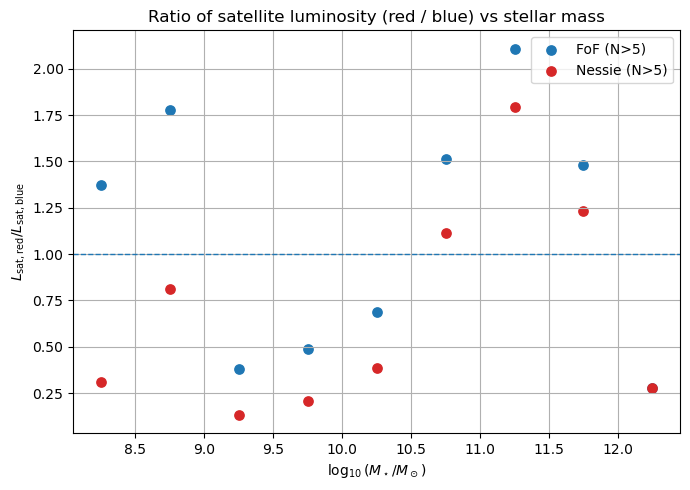

In [128]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Definitions
# -----------------------------
x_col = "log_stellar_mass"
bin_w = 0.5

mag_col = "total_ab_dust_Z_VISTA"
M_sun_Z_AB = 4.51  # adjust if needed

min_members = 5
fof_ncol = "n_group_fof"
nessie_ncol = "nessie_group_n"

# -----------------------------
# mag -> luminosity
# -----------------------------
def mag_to_Lsun(M_abs, M_sun=M_sun_Z_AB):
    M_abs = np.asarray(M_abs, dtype=float)
    return 10.0 ** (-0.4 * (M_abs - M_sun))

# -----------------------------
# Filter groups with >5 members
# -----------------------------
gals_fof = gals[gals[fof_ncol].notna() & (gals[fof_ncol] > min_members)].copy()
gals_nessie = gals[gals[nessie_ncol].notna() & (gals[nessie_ncol] > min_members)].copy()

# -----------------------------
# Stellar mass bins
# -----------------------------
x_all = np.concatenate([
    gals_fof[x_col].dropna().to_numpy(),
    gals_nessie[x_col].dropna().to_numpy()
])

xmin = np.floor(x_all.min() / bin_w) * bin_w
xmax = np.ceil(x_all.max() / bin_w) * bin_w

x_bins = np.arange(xmin, xmax + bin_w, bin_w)
x_centres = 0.5 * (x_bins[:-1] + x_bins[1:])

# -----------------------------
# Compute Lsat_red / Lsat_blue
# -----------------------------
def binned_Lsat_red_blue_ratio(df, is_satellite_mask_fn):
    df = df.copy()
    df["L_Z_Lsun"] = mag_to_Lsun(df[mag_col].to_numpy())

    ratios = []

    for smin, smax in zip(x_bins[:-1], x_bins[1:]):
        in_bin = (df[x_col] >= smin) & (df[x_col] < smax)
        is_sat = is_satellite_mask_fn(df)

        sat = df[in_bin & is_sat]

        sat_red = sat[sat["is_red"].astype(bool)]
        sat_blue = sat[~sat["is_red"].astype(bool)]

        if len(sat_red) == 0 or len(sat_blue) == 0:
            ratios.append(np.nan)
            continue

        Lred = np.nansum(sat_red["L_Z_Lsun"])
        Lblue = np.nansum(sat_blue["L_Z_Lsun"])

        ratios.append(Lred / Lblue if Lblue > 0 else np.nan)

    return np.array(ratios)

# -----------------------------
# Compute ratios
# -----------------------------
ratio_fof = binned_Lsat_red_blue_ratio(
    gals_fof,
    lambda d: ~d["is_bcg"].astype(bool)
)

ratio_nessie = binned_Lsat_red_blue_ratio(
    gals_nessie,
    lambda d: ~d["is_nessie_bcg"].astype(bool)
)

# -----------------------------
# Plot (overlay)
# -----------------------------
plt.figure(figsize=(7,5))

plt.scatter(
    x_centres,
    ratio_fof,
    color="tab:blue",
    label=f"FoF (N>{min_members})",
    s=45
)

plt.scatter(
    x_centres,
    ratio_nessie,
    color="tab:red",
    label=f"Nessie (N>{min_members})",
    s=45
)

plt.axhline(1.0, linestyle="--", linewidth=1)

plt.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
plt.ylabel(r"$L_{\rm sat,red} / L_{\rm sat,blue}$")
#plt.yscale("log")

plt.grid(True, which="both")
plt.legend()

plt.title(
    "Ratio of satellite luminosity (red / blue) vs stellar mass"
)

plt.tight_layout()
plt.savefig("../plots/Lsat_red_blue_ratio_overlay.png", dpi=300)
plt.show()

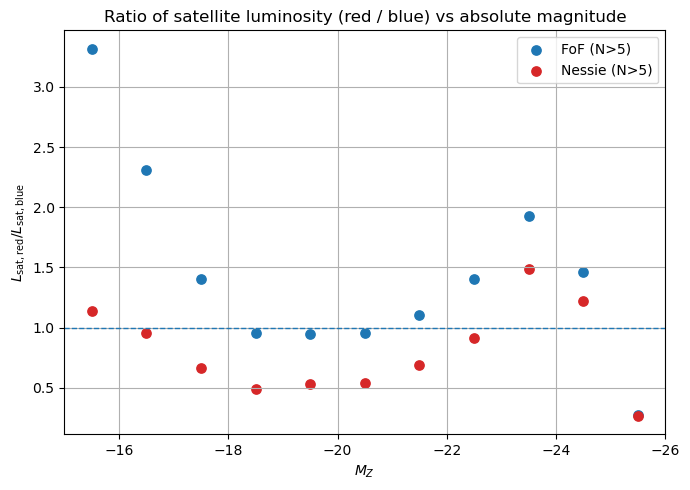

In [135]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Definitions
# -----------------------------
mag_xcol = "total_ab_dust_Z_VISTA"   # x-axis binning in absolute magnitude
bin_w = 1                    # mag bin width (change if you want)

# luminosity conversion (still needed for Lsat sums)
M_sun_Z_AB = 4.51                   # adjust if needed

min_members = 5
fof_ncol = "n_group_fof"
nessie_ncol = "nessie_group_n"

# -----------------------------
# mag -> luminosity (L/Lsun)
# -----------------------------
def mag_to_Lsun(M_abs, M_sun=M_sun_Z_AB):
    M_abs = np.asarray(M_abs, dtype=float)
    return 10.0 ** (-0.4 * (M_abs - M_sun))

# -----------------------------
# Filter groups with >5 members
# -----------------------------
gals_fof = gals[gals[fof_ncol].notna() & (gals[fof_ncol] > min_members)].copy()
gals_nessie = gals[gals[nessie_ncol].notna() & (gals[nessie_ncol] > min_members)].copy()

# -----------------------------
# Define consistent magnitude bins across both panels
# (note: more negative = brighter)
# -----------------------------
m_all = np.concatenate([
    gals_fof[mag_xcol].dropna().to_numpy(),
    gals_nessie[mag_xcol].dropna().to_numpy()
])

mmin = np.floor(m_all.min() / bin_w) * bin_w
mmax = np.ceil(m_all.max() / bin_w) * bin_w
m_bins = np.arange(mmin, mmax + bin_w, bin_w)
m_centres = 0.5 * (m_bins[:-1] + m_bins[1:])

# -----------------------------
# Binned ratio: sum(Lsat_red) / sum(Lsat_blue) in MAGNITUDE bins
#   satellites only
# -----------------------------
def binned_Lsat_red_blue_ratio_magbins(df, is_satellite_mask_fn):
    df = df.copy()
    df["L_Z_Lsun"] = mag_to_Lsun(df[mag_xcol].to_numpy())

    ratios = []

    for mlo, mhi in zip(m_bins[:-1], m_bins[1:]):
        in_bin = (df[mag_xcol] >= mlo) & (df[mag_xcol] < mhi)
        is_sat = is_satellite_mask_fn(df)

        sat = df[in_bin & is_sat]

        sat_red = sat[sat["is_red"].astype(bool)]
        sat_blue = sat[~sat["is_red"].astype(bool)]

        if len(sat_red) == 0 or len(sat_blue) == 0:
            ratios.append(np.nan)
            continue

        Lred = np.nansum(sat_red["L_Z_Lsun"])
        Lblue = np.nansum(sat_blue["L_Z_Lsun"])

        ratios.append(Lred / Lblue if Lblue > 0 else np.nan)

    return np.array(ratios)

# -----------------------------
# Compute ratios
# -----------------------------
ratio_fof_mag = binned_Lsat_red_blue_ratio_magbins(
    gals_fof,
    lambda d: ~d["is_bcg"].astype(bool)
)

ratio_nessie_mag = binned_Lsat_red_blue_ratio_magbins(
    gals_nessie,
    lambda d: ~d["is_nessie_bcg"].astype(bool)
)

# -----------------------------
# Plot (overlay)
# -----------------------------
plt.figure(figsize=(7, 5))

plt.scatter(
    m_centres,
    ratio_fof_mag,
    color="tab:blue",
    label=f"FoF (N>{min_members})",
    s=45
)

plt.scatter(
    m_centres,
    ratio_nessie_mag,
    color="tab:red",
    label=f"Nessie (N>{min_members})",
    s=45
)

plt.axhline(1.0, linestyle="--", linewidth=1)

plt.xlabel(r"$M_{Z}$")
plt.ylabel(r"$L_{\rm sat,red} / L_{\rm sat,blue}$")
plt.gca().invert_xaxis()  # brighter to the right (common convention); remove if you prefer

plt.grid(True, which="both")
plt.legend()
plt.title("Ratio of satellite luminosity (red / blue) vs absolute magnitude")

plt.tight_layout()
plt.savefig("../plots/Lsat_red_blue_ratio_overlay_magbins.png", dpi=300)
plt.show()

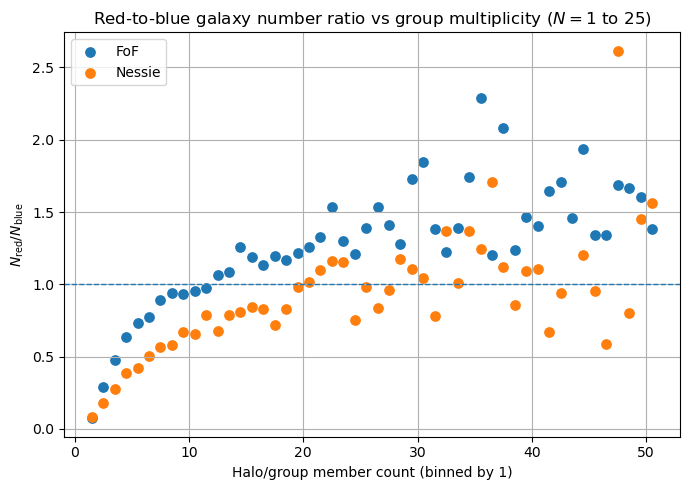

In [138]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Config
# -------------------------------------------------
min_n = 1
max_n = 50
# bins of 1 member: [1,2), [2,3), ... [25,26)
n_bins = np.arange(min_n, max_n + 2, 1)
n_centres = 0.5 * (n_bins[:-1] + n_bins[1:])

fof_ncol = "n_group_fof"
nessie_ncol = "nessie_group_n"

# -------------------------------------------------
# Helper: ratio N_red / N_blue in member-count bins
# -------------------------------------------------
def binned_red_blue_number_ratio(df, ncol):
    ratios = []

    # ensure boolean
    is_red = df["is_red"].astype(bool)

    for nlo, nhi in zip(n_bins[:-1], n_bins[1:]):
        in_bin = df[ncol].notna() & (df[ncol] >= nlo) & (df[ncol] < nhi)

        n_red = int(np.sum(in_bin & is_red))
        n_blue = int(np.sum(in_bin & (~is_red)))

        if n_blue == 0:
            ratios.append(np.nan)
        else:
            ratios.append(n_red / n_blue)

    return np.array(ratios)

# -------------------------------------------------
# Compute ratios for both groupings
# -------------------------------------------------
ratio_fof = binned_red_blue_number_ratio(gals, fof_ncol)
ratio_nessie = binned_red_blue_number_ratio(gals, nessie_ncol)

# -------------------------------------------------
# Plot (overlay)
# -------------------------------------------------
plt.figure(figsize=(7, 5))

plt.scatter(n_centres, ratio_fof,    s=45, label="FoF")
plt.scatter(n_centres, ratio_nessie, s=45, label="Nessie")

plt.axhline(1.0, linestyle="--", linewidth=1)

plt.xlabel("Halo/group member count (binned by 1)")
plt.ylabel(r"$N_{\rm red} / N_{\rm blue}$")
#plt.yscale("log")
plt.grid(True, which="both")
plt.legend()

plt.title(r"Red-to-blue galaxy number ratio vs group multiplicity ($N=1$ to $25$)")
plt.tight_layout()
plt.savefig("../plots/Nred_over_Nblue_vs_multiplicity_1to25.png", dpi=300)
plt.show()

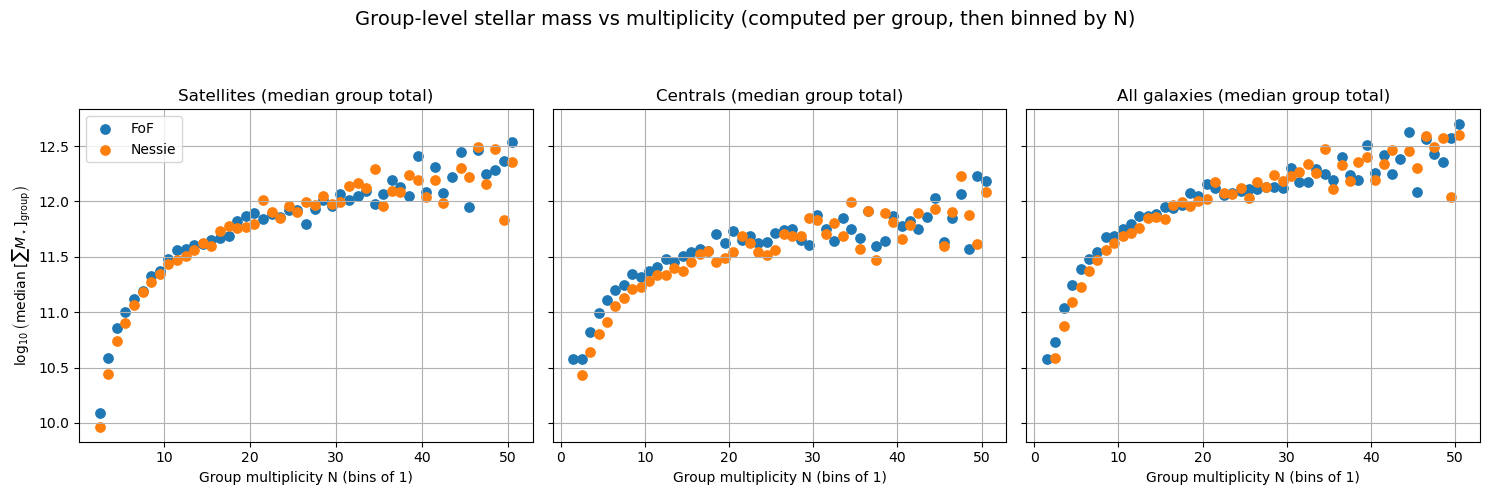

In [142]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Config
# -------------------------------------------------
min_n, max_n = 1, 50
n_bins = np.arange(min_n, max_n + 2, 1)
n_centres = 0.5 * (n_bins[:-1] + n_bins[1:])

mstar_col = "stellar_mass"  # MUST be linear mass, not log10 mass
eps = 1e-30

# group IDs (adjust if your columns differ)
fof_gid_col = "id_fof"
nessie_gid_col = "id_nessie"

# multiplicity columns
fof_ncol = "n_group_fof"
nessie_ncol = "nessie_group_n"

# choose statistic across groups in each N bin
STAT = "median"   # "mean" or "median"

# -------------------------------------------------
# Helper: group-level total masses, then bin by N
# -------------------------------------------------
def group_level_totals(df, gid_col, ncol, mask_fn):
    """
    Returns arrays: N_group, total_mass_per_group
    """
    use_cols = [gid_col, ncol, mstar_col]
    tmp = df[use_cols].copy()

    # keep only rows passing mask
    m = mask_fn(df)
    tmp = tmp[m]

    # drop invalid
    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna(subset=[gid_col, ncol, mstar_col])

    # exclude ungrouped if you use -1 convention
    tmp = tmp[tmp[gid_col] != -1]

    # group totals (sum mstar within each group for this selection)
    gsum = tmp.groupby(gid_col, sort=False)[mstar_col].sum()

    # group multiplicity N (same for all members; take first)
    gN = tmp.groupby(gid_col, sort=False)[ncol].first()

    # align
    gsum = gsum.loc[gN.index]

    return gN.to_numpy(dtype=float), gsum.to_numpy(dtype=float)

def binned_log10_group_totals(df, gid_col, ncol, mask_fn):
    """
    For each multiplicity bin, compute STAT( total_mass_per_group ) then log10.
    """
    N_group, Mtot_group = group_level_totals(df, gid_col, ncol, mask_fn)

    y = []
    for nlo, nhi in zip(n_bins[:-1], n_bins[1:]):
        in_bin = (N_group >= nlo) & (N_group < nhi)
        vals = Mtot_group[in_bin]
        vals = vals[np.isfinite(vals) & (vals > 0)]

        if vals.size == 0:
            y.append(np.nan)
            continue

        if STAT == "mean":
            agg = np.mean(vals)
        elif STAT == "median":
            agg = np.median(vals)
        else:
            raise ValueError("STAT must be 'mean' or 'median'")

        y.append(np.log10(agg + eps))

    return np.array(y)

# -------------------------------------------------
# Masks (per grouping)
# -------------------------------------------------
sat_mask_fof    = lambda d: ~d["is_bcg"].astype(bool)
cen_mask_fof    = lambda d:  d["is_bcg"].astype(bool)
all_mask        = lambda d:  np.ones(len(d), dtype=bool)

sat_mask_nessie = lambda d: ~d["is_nessie_bcg"].astype(bool)
cen_mask_nessie = lambda d:  d["is_nessie_bcg"].astype(bool)

# -------------------------------------------------
# Compute curves (group-level!)
# -------------------------------------------------
# Satellites
y_sat_fof    = binned_log10_group_totals(gals, fof_gid_col,    fof_ncol,    sat_mask_fof)
y_sat_nessie = binned_log10_group_totals(gals, nessie_gid_col, nessie_ncol, sat_mask_nessie)

# Centrals
y_cen_fof    = binned_log10_group_totals(gals, fof_gid_col,    fof_ncol,    cen_mask_fof)
y_cen_nessie = binned_log10_group_totals(gals, nessie_gid_col, nessie_ncol, cen_mask_nessie)

# All galaxies
y_all_fof    = binned_log10_group_totals(gals, fof_gid_col,    fof_ncol,    all_mask)
y_all_nessie = binned_log10_group_totals(gals, nessie_gid_col, nessie_ncol, all_mask)

# -------------------------------------------------
# Plot: 3 panels
# -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

def panel(ax, y_fof, y_nessie, title):
    ax.scatter(n_centres, y_fof, s=45, label="FoF")
    ax.scatter(n_centres, y_nessie, s=45, label="Nessie")
    ax.set_title(title)
    ax.set_xlabel("Group multiplicity N (bins of 1)")
    ax.grid(True)

panel(axes[0], y_sat_fof, y_sat_nessie, f"Satellites ({STAT} group total)")
panel(axes[1], y_cen_fof, y_cen_nessie, f"Centrals ({STAT} group total)")
panel(axes[2], y_all_fof, y_all_nessie, f"All galaxies ({STAT} group total)")

axes[0].set_ylabel(r"$\log_{10}\left(\mathrm{%s}\;[\sum M_\star]_{\rm group}\right)$" % STAT)

fig.suptitle("Group-level stellar mass vs multiplicity (computed per group, then binned by N)", fontsize=14)
axes[0].legend()

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("../plots/log10_group_total_stellar_mass_vs_multiplicity_panels_group_level.png", dpi=300)
plt.show()

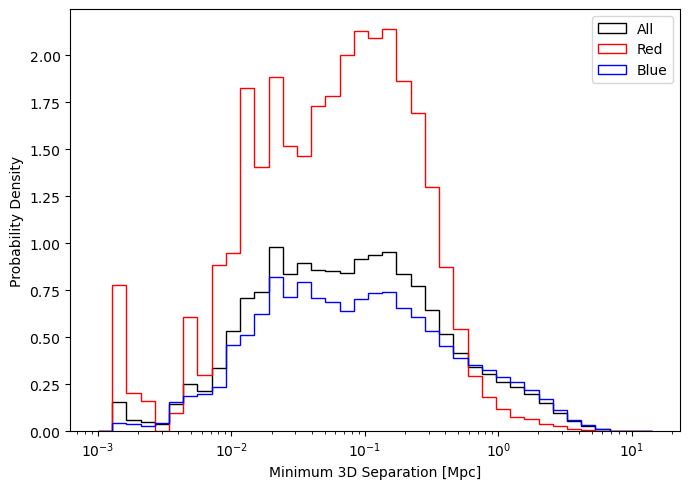

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

df = gals.copy()  # replace with your dataframe name
# --------------------------------------------------
# Required columns in your DataFrame:
# 'ra'  (deg)
# 'dec' (deg)
# 'z'   (redshift)
# 'is_red' (boolean)
# --------------------------------------------------

# replace with your dataframe name

# -------------------------
# Clean data
# -------------------------
df = df[(df['zcos'] > 0.3) & (df['zcos'] < 0.4) ]
cols = ['ra', 'dec', 'zcos', 'is_red']
df = df[cols].replace([np.inf, -np.inf], np.nan).dropna()

ra = np.deg2rad(df['ra'].values)
dec = np.deg2rad(df['dec'].values)
z = df['zcos'].values

# -------------------------
# Convert to comoving distance (Mpc)
# -------------------------
dc = cosmo.comoving_distance(z).to(u.Mpc).value

# -------------------------
# Convert to 3D Cartesian coordinates
# -------------------------
x = dc * np.cos(dec) * np.cos(ra)
y = dc * np.cos(dec) * np.sin(ra)
z_cart = dc * np.sin(dec)

coords = np.vstack([x, y, z_cart]).T

# -------------------------
# KDTree nearest neighbour search
# -------------------------
tree = cKDTree(coords)

# k=2 because nearest neighbour of each point is itself
distances, indices = tree.query(coords, k=2)

# second column = true nearest neighbour
min_sep = distances[:, 1]  # in Mpc

df['min_sep'] = min_sep

# -------------------------
# Split populations
# -------------------------
all_sep = df['min_sep'].values
red_sep = df[df['is_red'] == True]['min_sep'].values
blue_sep = df[df['is_red'] == False]['min_sep'].values

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(7,5))

bins = np.logspace(np.log10(all_sep.min()), 
                   np.log10(all_sep.max()), 
                   40)

#bins = np.linspace(all_sep.min(), all_sep.max(), 1000)

plt.hist(all_sep, bins=bins, color = 'black', histtype='step',
         label='All', density=True)#, log=True)

plt.hist(red_sep, bins=bins, color = 'r', histtype='step',
         label='Red', density=True)#, log=True)

plt.hist(blue_sep, bins=bins, color='blue', histtype='step',
         label='Blue', density=True)#, log=True)

plt.xscale('log')
plt.xlabel('Minimum 3D Separation [Mpc]')
plt.ylabel('Probability Density')
#plt.xlim(0 , 2)
plt.legend()
plt.tight_layout()
plt.show()

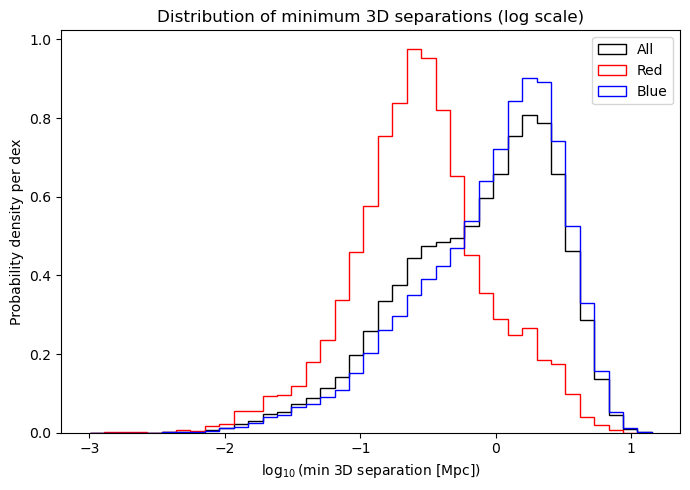

In [182]:
# --- guard against exact zeros (duplicates) ---
eps = 1e-6  # Mpc; just to avoid log(0) if needed
all_sep = np.clip(all_sep, eps, None)
red_sep = np.clip(red_sep, eps, None)
blue_sep = np.clip(blue_sep, eps, None)

log_all = np.log10(all_sep)
log_red = np.log10(red_sep)
log_blue = np.log10(blue_sep)

plt.figure(figsize=(7,5))

log_bins = np.linspace(log_all.min(), log_all.max(), 40)

plt.hist(log_all, bins=log_bins, histtype="step", density=True, color="black", label="All")
plt.hist(log_red, bins=log_bins, histtype="step", density=True, color="r", label="Red")
plt.hist(log_blue, bins=log_bins, histtype="step", density=True, color="blue", label="Blue")

plt.title("Distribution of minimum 3D separations (log scale)")
plt.xlabel(r'$\log_{10}(\mathrm{min\ 3D\ separation\ [Mpc]})$')
plt.ylabel('Probability density per dex')
plt.legend()
plt.tight_layout()
plt.savefig("../plots/min_3D_separation_log_histogram.png", dpi=300)
plt.show()

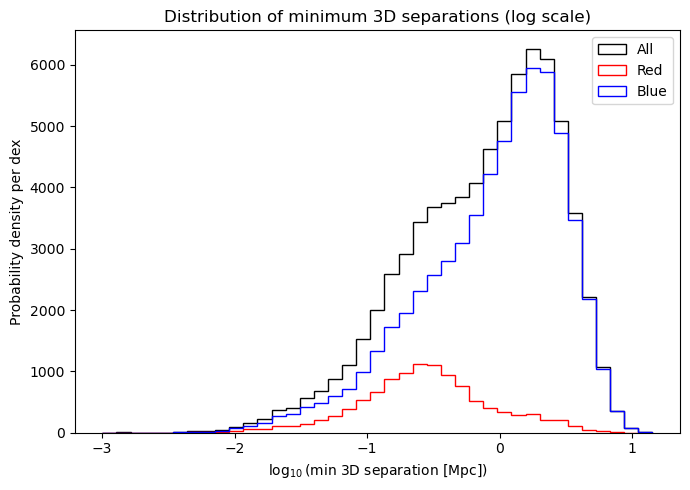

In [183]:
# --- guard against exact zeros (duplicates) ---
eps = 1e-6  # Mpc; just to avoid log(0) if needed
all_sep = np.clip(all_sep, eps, None)
red_sep = np.clip(red_sep, eps, None)
blue_sep = np.clip(blue_sep, eps, None)

log_all = np.log10(all_sep)
log_red = np.log10(red_sep)
log_blue = np.log10(blue_sep)

plt.figure(figsize=(7,5))

log_bins = np.linspace(log_all.min(), log_all.max(), 40)

plt.hist(log_all, bins=log_bins, histtype="step", color="black", label="All")
plt.hist(log_red, bins=log_bins, histtype="step",  color="r", label="Red")
plt.hist(log_blue, bins=log_bins, histtype="step", color="blue", label="Blue")

plt.title("Distribution of minimum 3D separations (log scale)")
plt.xlabel(r'$\log_{10}(\mathrm{min\ 3D\ separation\ [Mpc]})$')
plt.ylabel('Probability density per dex')
plt.legend()
plt.tight_layout()
#plt.savefig("../plots/min_3D_separation_log_histogram.png", dpi=300)
plt.show()

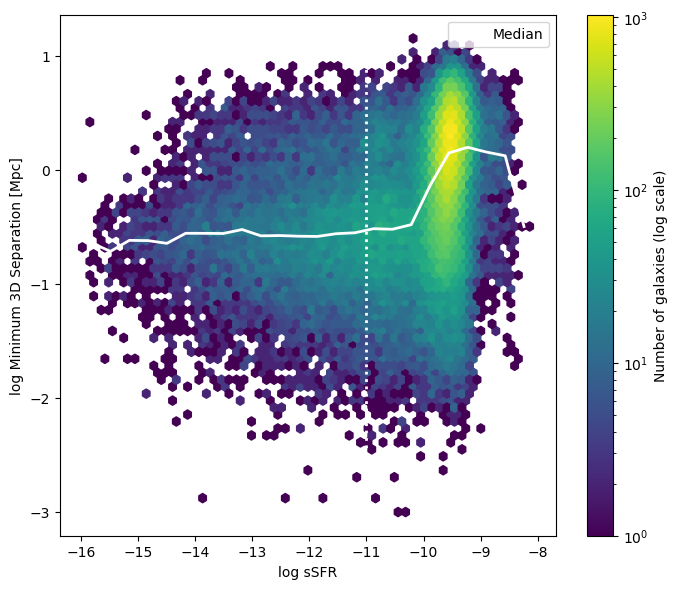

In [188]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from matplotlib.colors import LogNorm

df = gals.copy()

# ----------------------------------------
# Redshift slice
# ----------------------------------------
df = df[(df['zcos'] > 0.3) & (df['zcos'] < 0.4)]

cols = ['ra', 'dec', 'zcos', 'log_sSFR']
df = df[cols].replace([np.inf, -np.inf], np.nan).dropna()

# ----------------------------------------
# Nearest neighbour calculation
# ----------------------------------------
ra = np.deg2rad(df['ra'].values)
dec = np.deg2rad(df['dec'].values)
z = df['zcos'].values

dc = cosmo.comoving_distance(z).to(u.Mpc).value

x = dc * np.cos(dec) * np.cos(ra)
y = dc * np.cos(dec) * np.sin(ra)
z_cart = dc * np.sin(dec)

coords = np.vstack([x, y, z_cart]).T

tree = cKDTree(coords)
distances, _ = tree.query(coords, k=2)

min_sep = distances[:, 1]
min_sep = np.clip(min_sep, 1e-6, None)

df['log_min_sep'] = np.log10(min_sep)

# ----------------------------------------
# Clip log_sSFR range
# ----------------------------------------
df = df[df['log_sSFR'] >= -16]

xvals = df['log_sSFR'].values
yvals = df['log_min_sep'].values

# ----------------------------------------
# Plot: log-density hexbin
# ----------------------------------------
plt.figure(figsize=(7,6))

hb = plt.hexbin(
    xvals,
    yvals,
    gridsize=60,
    cmap="viridis",
    norm=LogNorm(),
    mincnt=1
)

cb = plt.colorbar(hb)
cb.set_label("Number of galaxies (log scale)")

# ----------------------------------------
# Median trend
# ----------------------------------------
bins = np.linspace(xvals.min(), xvals.max(), 25)
bin_centres = 0.5 * (bins[:-1] + bins[1:])

med = []
for i in range(len(bins)-1):
    m = (xvals >= bins[i]) & (xvals < bins[i+1])
    med.append(np.nanmedian(yvals[m]) if np.sum(m) > 5 else np.nan)

plt.plot(bin_centres, med, color='white', lw=2, label='Median')

# ----------------------------------------
# Vertical line at -11
# ----------------------------------------
plt.axvline(-11, color='white', linestyle=':', lw=2)

plt.xlabel('log sSFR')
plt.ylabel('log Minimum 3D Separation [Mpc]')
plt.legend()
plt.tight_layout()
plt.show()

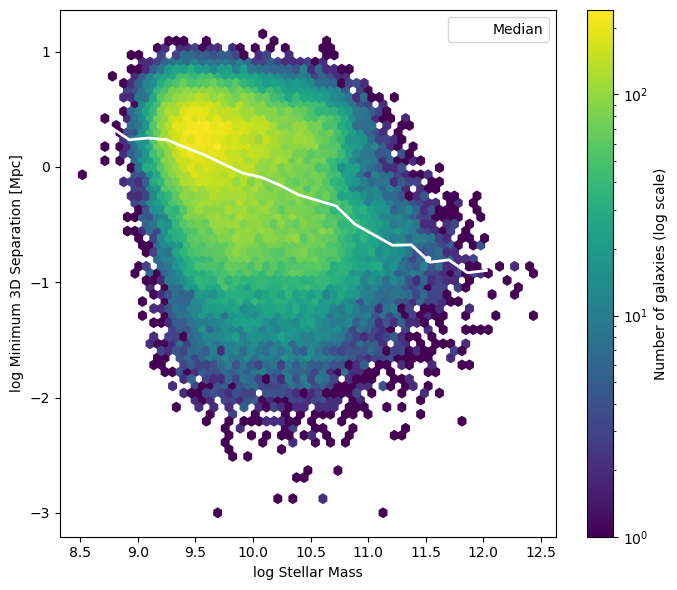

In [191]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from matplotlib.colors import LogNorm

df = gals.copy()

# ----------------------------------------
# Redshift slice
# ----------------------------------------
df = df[(df['zcos'] > 0.3) & (df['zcos'] < 0.4)]

cols = ['ra', 'dec', 'zcos', 'log_sSFR', 'log_stellar_mass']
df = df[cols].replace([np.inf, -np.inf], np.nan).dropna()

# ----------------------------------------
# Nearest neighbour calculation
# ----------------------------------------
ra = np.deg2rad(df['ra'].values)
dec = np.deg2rad(df['dec'].values)
z = df['zcos'].values

dc = cosmo.comoving_distance(z).to(u.Mpc).value

x = dc * np.cos(dec) * np.cos(ra)
y = dc * np.cos(dec) * np.sin(ra)
z_cart = dc * np.sin(dec)

coords = np.vstack([x, y, z_cart]).T

tree = cKDTree(coords)
distances, _ = tree.query(coords, k=2)

min_sep = distances[:, 1]
min_sep = np.clip(min_sep, 1e-6, None)

df['log_min_sep'] = np.log10(min_sep)

# ----------------------------------------
# Clip log_sSFR range
# ----------------------------------------
#df = df[df['log_sSFR'] >= -16]

xvals = df['log_stellar_mass'].values
yvals = df['log_min_sep'].values

# ----------------------------------------
# Plot: log-density hexbin
# ----------------------------------------
plt.figure(figsize=(7,6))

hb = plt.hexbin(
    xvals,
    yvals,
    gridsize=60,
    cmap="viridis",
    norm=LogNorm(),
    mincnt=1
)

cb = plt.colorbar(hb)
cb.set_label("Number of galaxies (log scale)")

# ----------------------------------------
# Median trend
# ----------------------------------------
bins = np.linspace(xvals.min(), xvals.max(), 25)
bin_centres = 0.5 * (bins[:-1] + bins[1:])

med = []
for i in range(len(bins)-1):
    m = (xvals >= bins[i]) & (xvals < bins[i+1])
    med.append(np.nanmedian(yvals[m]) if np.sum(m) > 5 else np.nan)

plt.plot(bin_centres, med, color='white', lw=2, label='Median')

# ----------------------------------------
# Vertical line at -11
# ----------------------------------------
#plt.axvline(-11, color='white', linestyle=':', lw=2)

plt.xlabel('log Stellar Mass')
plt.ylabel('log Minimum 3D Separation [Mpc]')
plt.legend()
plt.tight_layout()
plt.show()